Input Image (224×224)
        ↓
  Patchify → 196 patches (16×16 each)
        ↓
  Random Mask → Keep 25% = 49 patches
        ↓
┌─────────────────────────┐
│  ENCODER (ViT-Base)     │  ← Only sees 49 visible patches
│  768-dim, 12 layers     │  ← ~86M params, does heavy lifting
└─────────────────────────┘
        ↓ (project 768→384)
┌─────────────────────────┐
│  DECODER (ViT-Small)    │  ← Sees 49 encoded + 147 mask tokens
│  384-dim, 12 layers     │  ← ~22M params, lightweight
└─────────────────────────┘
        ↓
  196 reconstructed patches
        ↓
  MSE Loss (only on 147 masked patches)

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from pathlib import Path
from torch.optim.lr_scheduler import CosineAnnealingLR
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"GPU count       : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}        : {torch.cuda.get_device_name(i)}")

PyTorch version : 2.9.0+cu126
CUDA available  : True
GPU count       : 2
  GPU 0        : Tesla T4
  GPU 1        : Tesla T4


In [15]:
class MAEConfig:
    # Image
    image_size   = 224
    patch_size   = 16
    in_channels  = 3
    num_patches  = (224 // 16) ** 2          # 196

    # Masking
    mask_ratio   = 0.75
    num_visible  = int(num_patches * (1 - mask_ratio))  # 49

    # Encoder — ViT-Base
    enc_dim      = 768
    enc_layers   = 12
    enc_heads    = 12
    enc_mlp_ratio = 4

    # Decoder — ViT-Small
    dec_dim      = 384
    dec_layers   = 12
    dec_heads    = 6
    dec_mlp_ratio = 4

    # Training
    batch_size   = 32
    epochs       = 5
    base_lr      = 1.5e-4
    weight_decay = 0.05
    grad_clip    = 1.0
    num_workers  = 4

    # ✅ Correct dataset path
    data_path    = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'

cfg = MAEConfig()
print(f"\nPatches : {cfg.num_patches} total | {cfg.num_visible} visible | "
      f"{cfg.num_patches - cfg.num_visible} masked")

# Quick sanity-check that the path is reachable
assert os.path.exists(cfg.data_path), f"Path not found: {cfg.data_path}"
print(f"Dataset root    : {cfg.data_path}")
print(f"Contents        : {os.listdir(cfg.data_path)}")



Patches : 196 total | 49 visible | 147 masked
Dataset root    : /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200
Contents        : ['words.txt', 'wnids.txt', 'tiny-imagenet-200', 'val', 'test', 'train']


In [16]:
class TinyImageNetVal(Dataset):
    """
    Reads TinyImageNet validation images directly from the flat
    'images/' folder plus 'val_annotations.txt'.
    No folder restructuring needed.
    """
    def __init__(self, val_dir, transform=None):
        self.img_dir   = os.path.join(val_dir, 'images')
        self.transform = transform
        self.samples   = []

        annotations = os.path.join(val_dir, 'val_annotations.txt')
        with open(annotations) as f:
            for line in f:
                parts    = line.strip().split('\t')
                filename = parts[0]
                class_id = parts[1]
                self.samples.append((os.path.join(self.img_dir, filename), class_id))

        self.classes      = sorted(set(s[1] for s in self.samples))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        print(f"Val   : {len(self.samples)} images | {len(self.classes)} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, class_id = self.samples[idx]
        label = self.class_to_idx[class_id]
        img   = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


def build_dataloaders(cfg):
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(cfg.image_size, scale=(0.2, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    train_ds = ImageFolder(os.path.join(cfg.data_path, 'train'), transform=train_tf)
    val_ds   = TinyImageNetVal(os.path.join(cfg.data_path, 'val'), transform=val_tf)

    print(f"Train : {len(train_ds)} images")

    train_dl = DataLoader(train_ds, batch_size=cfg.batch_size,
                          shuffle=True,  num_workers=cfg.num_workers,
                          pin_memory=True, drop_last=True)
    val_dl   = DataLoader(val_ds,   batch_size=cfg.batch_size,
                          shuffle=False, num_workers=cfg.num_workers,
                          pin_memory=True)
    return train_dl, val_dl


In [19]:
# ── Patch Embedding ─────────────────────────────────────────
class PatchEmbed(nn.Module):
    """
    Splits image into non-overlapping patches and linearly
    projects each patch to embed_dim.
    (B, 3, 224, 224) → (B, 196, embed_dim)
    """
    def __init__(self, image_size=224, patch_size=16,
                 in_channels=3, embed_dim=768):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        # Conv2d with kernel=stride=patch_size is identical to
        # slicing + linear projection but is a single fused CUDA op.
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)        # (B, D, 14, 14)
        x = x.flatten(2)        # (B, D, 196)
        x = x.transpose(1, 2)  # (B, 196, D)
        return x


# ── Sinusoidal 2-D Positional Embedding ─────────────────────
def get_2d_sincos_pos_embed(embed_dim, grid_size):
    """
    Fixed 2-D sinusoidal positional embeddings.
    Returns numpy array (grid_size², embed_dim).
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid   = np.meshgrid(grid_w, grid_h)
    grid   = np.stack(grid, axis=0).reshape(2, 1, grid_size, grid_size)
    emb_h  = _sincos_1d(embed_dim // 2, grid[0])
    emb_w  = _sincos_1d(embed_dim // 2, grid[1])
    return np.concatenate([emb_h, emb_w], axis=1)

def _sincos_1d(embed_dim, pos):
    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega = 1.0 / (10000 ** (omega / (embed_dim // 2)))
    pos   = pos.reshape(-1)
    out   = np.einsum('m,d->md', pos, omega)
    return np.concatenate([np.sin(out), np.cos(out)], axis=1)


# ── Multi-Head Self-Attention ────────────────────────────────
class Attention(nn.Module):
    """
    Standard scaled dot-product multi-head self-attention.
    scale = 1/√d_k prevents softmax saturation for large d_k.
    """
    def __init__(self, dim, num_heads=8, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(dim, dim * 3, bias=True)
        self.proj      = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj_drop(self.proj(x))


# ── Feed-Forward MLP ─────────────────────────────────────────
class MLP(nn.Module):
    """
    Two-layer MLP with GELU activation.
    expand (×4) → contract pattern adds non-linear capacity.
    """
    def __init__(self, in_features, hidden_features=None,
                 out_features=None, drop=0.):
        super().__init__()
        h = hidden_features or in_features * 4
        o = out_features    or in_features
        self.fc1  = nn.Linear(in_features, h)
        self.act  = nn.GELU()
        self.fc2  = nn.Linear(h, o)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))


# ── Transformer Block ────────────────────────────────────────
class TransformerBlock(nn.Module):
    """
    Pre-LN Transformer block: LayerNorm → sub-layer → residual.
    Pre-LN is more training-stable than the original Post-LN.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4.,
                 drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = Attention(dim, num_heads, attn_drop, drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, int(dim * mlp_ratio), drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [20]:
class MAEEncoder(nn.Module):
    """
    Processes ONLY visible (unmasked) patches.
    This asymmetry means the encoder never wastes compute on
    mask tokens, making training ~4× faster than a full ViT.
    """
    def __init__(self, cfg):
        super().__init__()
        self.mask_ratio  = cfg.mask_ratio
        self.num_patches = cfg.num_patches

        self.patch_embed = PatchEmbed(cfg.image_size, cfg.patch_size,
                                      cfg.in_channels, cfg.enc_dim)

        # CLS token aggregates global context for downstream tasks
        self.cls_token = nn.Parameter(torch.zeros(1, 1, cfg.enc_dim))

        # Fixed sinusoidal positional embeddings (no extra params)
        pe = get_2d_sincos_pos_embed(cfg.enc_dim,
                                     cfg.image_size // cfg.patch_size)
        self.register_buffer('pos_embed',
                             torch.from_numpy(pe).float().unsqueeze(0))

        self.blocks = nn.ModuleList([
            TransformerBlock(cfg.enc_dim, cfg.enc_heads, cfg.enc_mlp_ratio)
            for _ in range(cfg.enc_layers)
        ])
        self.norm = nn.LayerNorm(cfg.enc_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
        w = self.patch_embed.proj.weight
        nn.init.xavier_uniform_(w.view(w.size(0), -1))

    def random_masking(self, x, mask_ratio):
        """
        Shuffle patches with random noise, keep first N (= 25 %).
        ids_restore is the INVERSE permutation used later to
        reconstruct original patch order in the decoder.
        """
        B, N, D  = x.shape
        num_keep = int(N * (1 - mask_ratio))

        noise        = torch.rand(B, N, device=x.device)
        ids_shuffle  = noise.argsort(dim=1)
        ids_restore  = ids_shuffle.argsort(dim=1)
        ids_keep     = ids_shuffle[:, :num_keep]

        x_vis = torch.gather(
            x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))

        # mask: 1 = masked, 0 = visible  (used for loss)
        mask = torch.ones(B, N, device=x.device)
        mask[:, :num_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)

        return x_vis, mask, ids_restore

    def forward(self, imgs, mask_ratio=None):
        if mask_ratio is None:
            mask_ratio = self.mask_ratio

        x = self.patch_embed(imgs)          # (B, 196, 768)
        x = x + self.pos_embed             # add position before masking

        x, mask, ids_restore = self.random_masking(x, mask_ratio)
        # x: (B, 49, 768)

        cls = self.cls_token.expand(x.size(0), -1, -1)
        x   = torch.cat([cls, x], dim=1)   # (B, 50, 768)

        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        return x, mask, ids_restore

In [22]:
class MAEDecoder(nn.Module):
    """
    Receives encoder output (49 visible tokens) + learnable
    mask tokens (147) and reconstructs all 196 patches.

    Learnable mask tokens prevent the decoder from trivially
    detecting masked positions via a fixed sentinel value.
    """
    def __init__(self, cfg):
        super().__init__()
        self.num_patches = cfg.num_patches
        self.dec_dim     = cfg.dec_dim

        # Bridge: encoder dim → decoder dim
        self.encoder_proj = nn.Linear(cfg.enc_dim, cfg.dec_dim)

        self.mask_token = nn.Parameter(torch.zeros(1, 1, cfg.dec_dim))

        pe = get_2d_sincos_pos_embed(cfg.dec_dim,
                                     cfg.image_size // cfg.patch_size)
        self.register_buffer('pos_embed',
                             torch.from_numpy(pe).float().unsqueeze(0))

        self.blocks = nn.ModuleList([
            TransformerBlock(cfg.dec_dim, cfg.dec_heads, cfg.dec_mlp_ratio)
            for _ in range(cfg.dec_layers)
        ])
        self.norm     = nn.LayerNorm(cfg.dec_dim)
        # Each patch token → patch_size² × 3 pixel values
        self.pred_head = nn.Linear(cfg.dec_dim,
                                   cfg.patch_size ** 2 * cfg.in_channels)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, encoded, ids_restore):
        B = encoded.size(0)

        x = self.encoder_proj(encoded)      # (B, 50, 384)
        cls_tok      = x[:, :1, :]          # (B,  1, 384)
        patch_tokens = x[:, 1:, :]          # (B, 49, 384)

        num_masked  = self.num_patches - patch_tokens.size(1)   # 147
        mask_tokens = self.mask_token.expand(B, num_masked, -1)

        # Concatenate then UNSHUFFLE to original spatial order
        full = torch.cat([patch_tokens, mask_tokens], dim=1)    # (B,196,384)
        full = torch.gather(
            full, 1,
            ids_restore.unsqueeze(-1).expand(-1, -1, self.dec_dim))

        x = torch.cat([cls_tok, full], dim=1)   # (B, 197, 384)
        x[:, 1:, :] += self.pos_embed           # add positions to patches

        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        x    = x[:, 1:, :]          # drop CLS  (B, 196, 384)
        pred = self.pred_head(x)    # (B, 196, 768)
        return pred


In [23]:
class MAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg     = cfg
        self.encoder = MAEEncoder(cfg)
        self.decoder = MAEDecoder(cfg)

    # ── helpers ──────────────────────────────────────────────
    def patchify(self, imgs):
        """(B, 3, 224, 224) → (B, 196, 768)"""
        p  = self.cfg.patch_size
        h  = w = imgs.shape[2] // p
        x  = imgs.reshape(imgs.shape[0], 3, h, p, w, p)
        x  = x.permute(0, 2, 4, 1, 3, 5)
        return x.reshape(imgs.shape[0], h * w, p * p * 3)

    def unpatchify(self, x):
        """(B, 196, 768) → (B, 3, 224, 224)"""
        p  = self.cfg.patch_size
        h  = w = int(x.shape[1] ** 0.5)
        x  = x.reshape(x.shape[0], h, w, 3, p, p)
        x  = x.permute(0, 3, 1, 4, 2, 5)
        return x.reshape(x.shape[0], 3, h * p, w * p)

    # ── loss ─────────────────────────────────────────────────
    def compute_loss(self, imgs, pred, mask):
        """
        MSE only on masked patches.
        Visible patches are ignored so the model can't cheat
        by copying what the encoder already saw.
        Per-patch normalisation equalises bright/dark patches.
        """
        target = self.patchify(imgs)
        mean   = target.mean(dim=-1, keepdim=True)
        var    = target.var(dim=-1,  keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()

        loss = ((pred - target) ** 2).mean(dim=-1)   # (B, 196)
        loss = (loss * mask).sum() / mask.sum()       # masked only
        return loss

    def forward(self, imgs, mask_ratio=None):
        latent, mask, ids_restore = self.encoder(imgs, mask_ratio)
        pred  = self.decoder(latent, ids_restore)
        loss  = self.compute_loss(imgs, pred, mask)
        return loss, pred, mask


In [24]:
def build_training(cfg):
    model = MAE(cfg)

    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs via DataParallel")
        model = nn.DataParallel(model)
    model = model.cuda()

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters : {total/1e6:.1f}M total | {trainable/1e6:.1f}M trainable")

    # AdamW decouples weight-decay from the gradient update —
    # essential for stable Transformer training.
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.base_lr,
        betas=(0.9, 0.95),
        weight_decay=cfg.weight_decay,
    )

    # Cosine schedule: high LR explores, gradual decay fine-tunes.
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=1e-6)

    # AMP: FP16 halves memory, hits T4 tensor cores (2-3× speedup).
    scaler = GradScaler()

    return model, optimizer, scheduler, scaler


In [31]:
def train_one_epoch(model, loader, optimizer, scaler, cfg, epoch):
    model.train()
    total_loss = 0.0

    for step, (imgs, _) in enumerate(loader):
        imgs = imgs.cuda(non_blocking=True)
        optimizer.zero_grad()

        with autocast():
            loss, _, _ = model(imgs)

        # DataParallel returns one loss per GPU → average to scalar
        if loss.dim() > 0:
            loss = loss.mean()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        if step % 100 == 0:
            print(f"  Epoch {epoch:03d} | step {step:04d}/{len(loader)} "
                  f"| loss {loss.item():.4f}")

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    total = 0.0
    for imgs, _ in loader:
        imgs = imgs.cuda(non_blocking=True)
        with autocast():
            loss, _, _ = model(imgs)
        # DataParallel fix
        if loss.dim() > 0:
            loss = loss.mean()
        total += loss.item()
    return total / len(loader)


In [ ]:
train_loader, val_loader = build_dataloaders(cfg)
model, optimizer, scheduler, scaler = build_training(cfg)

train_losses, val_losses = [], []
best_val = float('inf')

for epoch in range(1, cfg.epochs + 1):
    tr_loss  = train_one_epoch(model, train_loader, optimizer, scaler, cfg, epoch)
    val_loss = validate(model, val_loader)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    print(f"\n{'='*55}")
    print(f"Epoch {epoch:03d}/{cfg.epochs}  "
          f"train={tr_loss:.4f}  val={val_loss:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}")
    print(f"{'='*55}\n")

    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': val_loss,
        }, '/kaggle/working/mae_best.pth')
        print(f"  ✓ Saved best model  (val={val_loss:.4f})\n")


Val   : 10000 images | 200 classes
Train : 100000 images
Using 2 GPUs via DataParallel
Parameters : 107.5M total | 107.5M trainable
  Epoch 001 | step 0000/3125 | loss 1.6452
  Epoch 001 | step 0100/3125 | loss 0.7116
  Epoch 001 | step 0200/3125 | loss 0.7877
  Epoch 001 | step 0300/3125 | loss 0.7819
  Epoch 001 | step 0400/3125 | loss 0.6724
  Epoch 001 | step 0500/3125 | loss 0.6610
  Epoch 001 | step 0600/3125 | loss 0.5971
  Epoch 001 | step 0700/3125 | loss 0.5932
  Epoch 001 | step 0800/3125 | loss 0.5900
  Epoch 001 | step 0900/3125 | loss 0.6414
  Epoch 001 | step 1000/3125 | loss 0.5289
  Epoch 001 | step 1100/3125 | loss 0.5889
  Epoch 001 | step 1200/3125 | loss 0.5551
  Epoch 001 | step 1300/3125 | loss 0.5338
  Epoch 001 | step 1400/3125 | loss 0.4791
  Epoch 001 | step 1500/3125 | loss 0.5895
  Epoch 001 | step 1600/3125 | loss 0.5523
  Epoch 001 | step 1700/3125 | loss 0.5712
  Epoch 001 | step 1800/3125 | loss 0.5361
  Epoch 001 | step 1900/3125 | loss 0.5502
  Epoch 

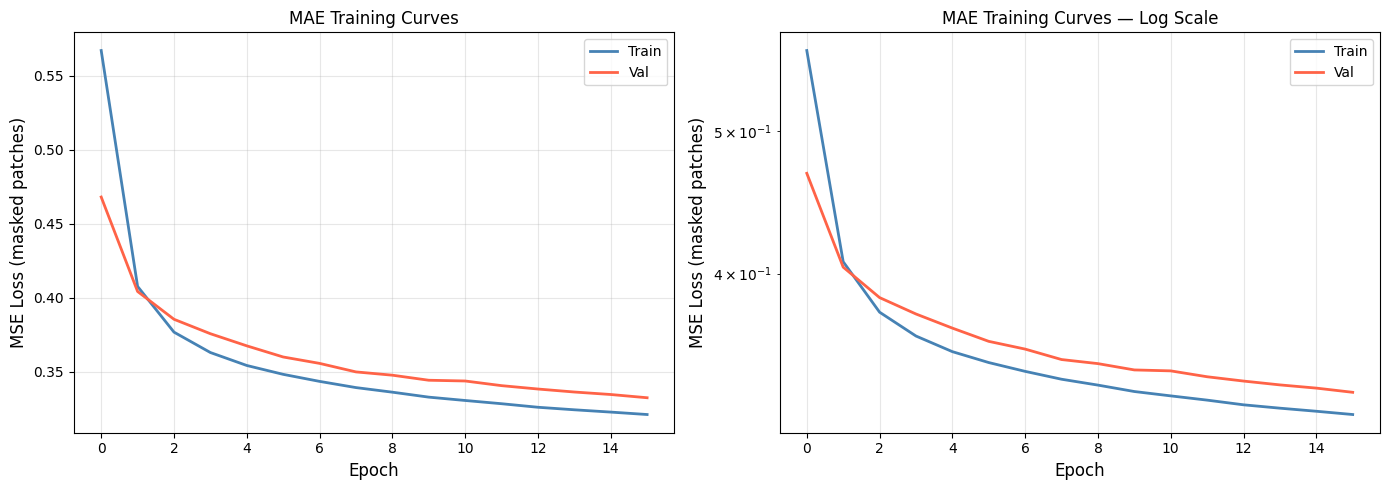

Saved → /kaggle/working/loss_curves.png


In [33]:
def plot_losses(train_losses, val_losses):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, logy in zip(axes, [False, True]):
        ax.plot(train_losses, label='Train', color='steelblue', lw=2)
        ax.plot(val_losses,   label='Val',   color='tomato',    lw=2)
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('MSE Loss (masked patches)', fontsize=12)
        ax.set_title('MAE Training Curves' + (' — Log Scale' if logy else ''))
        if logy:
            ax.set_yscale('log')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/kaggle/working/loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → /kaggle/working/loss_curves.png")

plot_losses(train_losses, val_losses)



PSNR : 12.99 ± 1.00 dB
SSIM : 0.4212 ± 0.0200


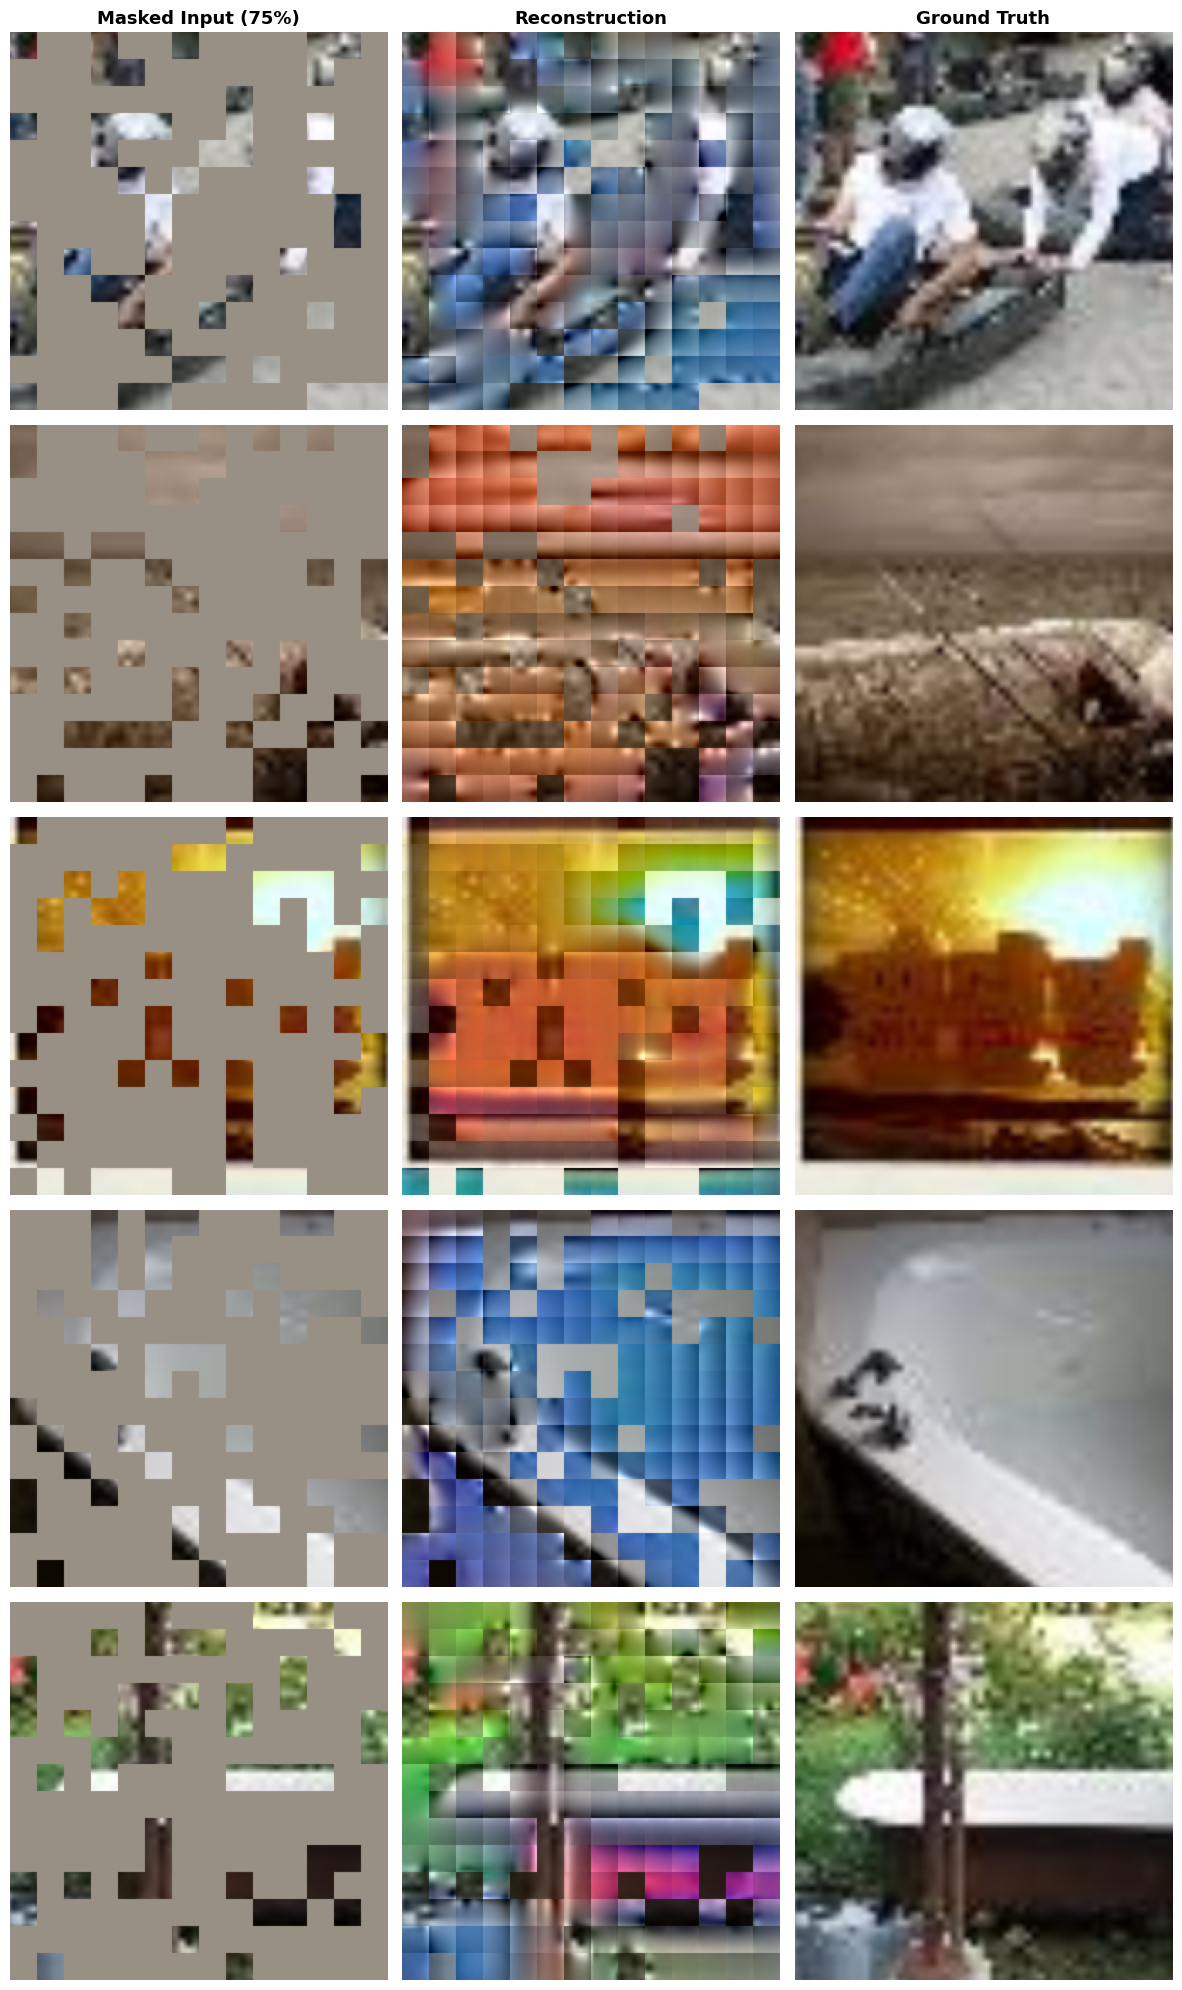

Saved → /kaggle/working/reconstructions.png


In [34]:
def denormalize(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)


def apply_mask_visual(img, mask, patch_size=16):
    """
    Grey out masked patches so we can see what the model
    actually received as input.
    """
    img  = img.clone()
    B, C, H, W = img.shape
    nh   = nw = H // patch_size
    mask = mask.view(B, nh, nw)
    for b in range(B):
        for i in range(nh):
            for j in range(nw):
                if mask[b, i, j] == 1:
                    img[b, :,
                        i*patch_size:(i+1)*patch_size,
                        j*patch_size:(j+1)*patch_size] = 0.5
    return img


@torch.no_grad()
def visualize_reconstructions(model, val_loader, cfg,
                               n=5, save='/kaggle/working/reconstructions.png'):
    model.eval()
    imgs, _ = next(iter(val_loader))
    imgs    = imgs[:n].cuda()

    with autocast():
        loss, pred, mask = model(imgs)

    # Unwrap DataParallel if present
    m = model.module if isinstance(model, nn.DataParallel) else model

    # Build composite: original where visible, prediction where masked
    pred_imgs   = m.unpatchify(pred)
    mask_expand = mask.unsqueeze(-1).repeat(1, 1, cfg.patch_size**2 * 3)
    mask_2d     = m.unpatchify(mask_expand)
    recon       = imgs * (1 - mask_2d) + pred_imgs * mask_2d

    # Masked input visualisation
    masked_vis  = apply_mask_visual(imgs, mask, cfg.patch_size)

    # Move to CPU & denormalise
    orig_list   = [denormalize(imgs[i].cpu())       for i in range(n)]
    mask_list   = [denormalize(masked_vis[i].cpu()) for i in range(n)]
    recon_list  = [denormalize(recon[i].cpu())      for i in range(n)]

    # ── PSNR / SSIM ──────────────────────────────────────────
    psnr_vals, ssim_vals = [], []
    for i in range(n):
        o  = (orig_list[i].permute(1,2,0).numpy()  * 255).astype(np.uint8)
        r  = (recon_list[i].permute(1,2,0).numpy() * 255).astype(np.uint8)
        psnr_vals.append(psnr_metric(o, r, data_range=255))
        ssim_vals.append(ssim_metric(o, r, data_range=255,
                                     channel_axis=-1, win_size=7))

    print(f"\nPSNR : {np.mean(psnr_vals):.2f} ± {np.std(psnr_vals):.2f} dB")
    print(f"SSIM : {np.mean(ssim_vals):.4f} ± {np.std(ssim_vals):.4f}")

    # ── Plot ─────────────────────────────────────────────────
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    col_titles = ['Masked Input (75%)', 'Reconstruction', 'Ground Truth']

    for i in range(n):
        row_imgs = [mask_list[i], recon_list[i], orig_list[i]]
        for j, (t, title) in enumerate(zip(row_imgs, col_titles)):
            ax = axes[i][j]
            ax.imshow(t.permute(1, 2, 0).numpy())
            ax.axis('off')
            if i == 0:
                ax.set_title(title, fontsize=13, fontweight='bold')
            if j == 1:
                ax.set_xlabel(
                    f'PSNR {psnr_vals[i]:.1f} dB  |  SSIM {ssim_vals[i]:.3f}',
                    fontsize=10)

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save}")

    return np.mean(psnr_vals), np.mean(ssim_vals)


psnr, ssim = visualize_reconstructions(model, val_loader, cfg)


In [35]:
import gradio as gr


def load_best_model(path, cfg):
    m    = MAE(cfg)
    ckpt = torch.load(path, map_location='cpu')
    sd   = {k.replace('module.', ''): v
            for k, v in ckpt['model_state_dict'].items()}
    m.load_state_dict(sd)
    m.eval()
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    return m.to(device)


inf_model = load_best_model('/kaggle/working/mae_best.pth', cfg)


def reconstruct(pil_img, mask_ratio=0.75):
    """Gradio inference: PIL image + mask ratio → three PIL images + metrics."""
    device = next(inf_model.parameters()).device

    tf = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    img_t = tf(pil_img).unsqueeze(0).to(device)

    with torch.no_grad(), autocast():
        _, pred, mask = inf_model(img_t, mask_ratio=mask_ratio)

    pred_full   = inf_model.unpatchify(pred)
    mask_expand = mask.unsqueeze(-1).repeat(1, 1, cfg.patch_size**2 * 3)
    mask_2d     = inf_model.unpatchify(mask_expand)
    recon       = img_t * (1 - mask_2d) + pred_full * mask_2d
    masked_inp  = apply_mask_visual(img_t, mask, cfg.patch_size)

    def to_pil(t):
        arr = denormalize(t[0].cpu()).permute(1, 2, 0).numpy()
        return Image.fromarray((arr * 255).astype(np.uint8))

    orig_pil    = to_pil(img_t)
    masked_pil  = to_pil(masked_inp)
    recon_pil   = to_pil(recon)

    psnr_v = psnr_metric(np.array(orig_pil), np.array(recon_pil), data_range=255)
    ssim_v = ssim_metric(np.array(orig_pil), np.array(recon_pil),
                         data_range=255, channel_axis=-1, win_size=7)

    metrics = f"PSNR : {psnr_v:.2f} dB     SSIM : {ssim_v:.4f}"
    return masked_pil, recon_pil, orig_pil, metrics


with gr.Blocks(title="MAE Reconstruction") as demo:
    gr.Markdown("# 🎭 Masked Autoencoder — Image Reconstruction")
    gr.Markdown(
        "Upload any image and watch the MAE reconstruct it "
        "from only 25 % of the patches."
    )

    with gr.Row():
        with gr.Column(scale=1):
            inp_img    = gr.Image(type="pil", label="Upload Image")
            mask_slide = gr.Slider(0.1, 0.9, value=0.75, step=0.05,
                                   label="Masking Ratio")
            run_btn    = gr.Button("Reconstruct ▶", variant="primary")
            metrics_tb = gr.Textbox(label="Quality Metrics", interactive=False)

        with gr.Column(scale=2):
            with gr.Row():
                out_masked = gr.Image(label="Masked Input")
                out_recon  = gr.Image(label="Reconstruction")
                out_orig   = gr.Image(label="Original")

    run_btn.click(
        fn=reconstruct,
        inputs=[inp_img, mask_slide],
        outputs=[out_masked, out_recon, out_orig, metrics_tb],
    )

demo.launch(share=True)   # share=True → public URL works on Kaggle

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://54d75f09ce8337b19c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
